<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Atmosphere Analysis 5 — Differential Flux Generation — MCEq

**Description:** Generates and saves the full height-differential atmospheric neutrino source
flux $\Phi(E,h;\theta)$ for the standard 10-bin $\cos\theta$ grid using MCEq.
MCEq is run in angle chunks of 6 to bound peak memory. Saved files are loaded and
visualised at the end.

**Physics:** MCEq cascade equation + depth-to-height transformation  

**Source:** MCEq (cascade-equation solver)  ·  `external.mceq.generator`


| # | Section |
|---|---------|
| [0](#0.-Theory-Summary) | **Theory Summary** |
| [1](#1.-Setup) | **Setup**: imports and configuration |
| [2](#2.-Generation-Parameters) | **Generation Parameters**: 2.1 physical model, 2.2 numerical grids, 2.3 smoothing, 2.4 particle list, 2.5 angle grid, 2.6 parallel \& save config |
| [3](#3.-Output-Run-Directory) | **Output Run Directory**: auto-increment `runXXXX` and build configs |
| [4](#4.-Generate-and-Save) | **Generate and Save**: chunked MCEq dispatch with `merge_generation_results` |
| [5](#5.-Verify-Output) | **Verify Output**: list saved files by particle |
| [6](#6.-Load-and-Inspect) | **Load and Inspect**: 6.1 load dataset, 6.2 summary, 6.3 energy spectra $\Phi(E;\theta)$, 6.4 height PDF $f(h|E,\theta)$, 6.5 differential flux $\Phi(E,h;\theta)$ heatmap |

## 0. Theory Summary

This notebook generates data; the full theoretical derivation is in
**Atmosphere Analysis 4** (`atmosphere4_Differential_Flux_MCEq_Analysis`).
The key quantities are recalled here for reference.

| Symbol | Definition | Source |
|--------|-----------|--------|
| $\Phi(E,X;\theta)$ | Cascade-equation solution at slant depth $X$ | MCEq |
| $Q_\text{eff}(E,X;\theta) = \max(d\Phi/dX,\,0)$ | Production source, clipped | tpeanuts |
| $X(h,\theta) = \frac{1}{\cos\theta}\int_h^\infty \rho\,dh^\prime$ | Slant-depth/altitude relation | MCEq density model |
| $f(h\|E,\theta)$ | Production-height PDF, $\int f\,dh = 1$ | tpeanuts |
| $\Phi(E,h;\theta)$ | Height-differential flux $= \Phi(E;\theta)\times f(h\|E,\theta)$ | tpeanuts |

**References:**
- A. Fedynitch et al., EPJ Web Conf. **99**, 08001 (2015) [MCEq]
- T. K. Gaisser & M. Honda, Ann. Rev. Nucl. Part. Sci. **52**, 153 (2002)

## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.external.honda import honda_cosz_centers
from tpeanuts.external.mceq.config import GridConfig, MCEqModelConfig, SmoothingConfig
from tpeanuts.external.mceq.generator import generate_flux_for_particles_angle_grid
from tpeanuts.medium.atmosphere.io import OutputConfig, load_directory
from tpeanuts.util.parallel import ParallelConfig
from tpeanuts.util.type import as_tensor

In [2]:
config     = load_notebook_config()
OUTPUT_DIR = config.output_dir('analysis', 'atmosphere','mceq_generator')
BASE_FLUX_DIR = config.output_root / 'data' / 'flux' / 'differential' / 'Honda'
SHOW_PLOTS = config.show_plots
print(f'Analysis output : {OUTPUT_DIR}')
print(f"Flux Output directory  : {BASE_FLUX_DIR}")
print(f'Data output root: {config.output_root}')

Analysis output : v:\output\analysis\atmosphere\mceq_generator
Flux Output directory  : v:\output\data\flux\differential\Honda
Data output root: v:\output


## 2. Generation Parameters

All parameters controlling the generation are defined here as module-level
constants so they can be inspected and changed without touching the run cell.

### 2.1 Physical Model

Select the hadronic interaction model, primary cosmic-ray flux model, and atmospheric
density profile. These choices set the cascade physics (see `MCEqModelConfig` docs
and atmosphere4 for the physical interpretation of each parameter).

In [3]:
INTERACTION_MODEL = "QGSJETII04"   # hadronic interaction model
PRIMARY_MODEL     = "PolyGonato"   # primary cosmic-ray spectrum
DENSITY_MODEL     = "ICECUBE"      # atmospheric density profile
MCEQ_INFO         = False          # suppress MCEq's internal logging

print(f'Interaction model : {INTERACTION_MODEL}')
print(f'Primary model     : {PRIMARY_MODEL}')
print(f'Density model     : {DENSITY_MODEL}')

Interaction model : QGSJETII04
Primary model     : PolyGonato
Density model     : ICECUBE


### 2.2 Numerical Grids

- **X grid**: 101 points from 1 to 1030 g/cm$^2$ — the depth grid on which MCEq
  integrates the cascade ODE from the top of the atmosphere to sea level.
- **h grid**: 501 points from 0 to 120 km — the altitude grid on which
  $f(h|E,\theta)$ and $\Phi(E,h;\theta)$ are reported.

In [4]:
X_OBS_GCM2  = 1030.0
X_GRID_GCM2 = torch.linspace(1.0, X_OBS_GCM2, 101, dtype=torch.float64)
H_GRID_KM   = torch.linspace(0.0, 120.0, 501, dtype=torch.float64)

print(f'X grid : {len(X_GRID_GCM2)} points, {float(X_GRID_GCM2[0]):.1f} - {float(X_GRID_GCM2[-1]):.1f} g/cm2')
print(f'h grid : {len(H_GRID_KM)} points, {float(H_GRID_KM[0]):.1f} - {float(H_GRID_KM[-1]):.1f} km')
print(f'X_obs  : {X_OBS_GCM2} g/cm2 (sea level)')

X grid : 101 points, 1.0 - 1030.0 g/cm2
h grid : 501 points, 0.0 - 120.0 km
X_obs  : 1030.0 g/cm2 (sea level)


### 2.3 Smoothing Configuration

Numerical differentiation of $\Phi(E,X;\theta)$ amplifies solver noise.
`method='spline'` fits a smoothing spline along $X$ before taking $d\Phi/dX$.
`positive_only=True` clips residual negative derivative values to zero.

In [5]:
SMOOTHING_METHOD = "spline"
SMOOTHING        = 1.0e-4
GAUSSIAN_SIGMA   = 2.0
POSITIVE_ONLY    = True
print(f'Smoothing: method={SMOOTHING_METHOD!r}, strength={SMOOTHING}, positive_only={POSITIVE_ONLY}')

Smoothing: method='spline', strength=0.0001, positive_only=True


### 2.4 Particle List

MCEq self-consistently predicts all four standard neutrino flavours from the same
cascade solve ($\pi/K \to \mu \to e$ decay chain). Tau neutrinos are not predicted
by MCEq directly and are omitted here.

In [6]:
PARTICLES = {
    "nue":      "nue",
    "antinue":  "antinue",
    "numu":     "numu",
    "antinumu": "antinumu",
    "nutau":     "nutau",
    "antinutau": "antinutau",
}
print(f'Particles ({len(PARTICLES)}): {list(PARTICLES)}')

Particles (6): ['nue', 'antinue', 'numu', 'antinumu', 'nutau', 'antinutau']


### 2.5 Angle Grid

Use the standard Honda 10-bin downward-going $\cos\theta$ grid
($\cos\theta \in [0.05, 0.95]$, step 0.1), converted to surface zenith angles.
This matches the angle convention used by the Honda generation notebook (atmosphere3)
so that MCEq and Honda outputs are directly comparable.

In [7]:
cosz_centers   = honda_cosz_centers()             # (20,) full Honda grid
cosz_down      = cosz_centers[cosz_centers > 0]   # (10,) downward-going only
THETA_GRID_DEG = torch.rad2deg(
    torch.acos(torch.as_tensor(cosz_down, dtype=torch.float64))
).sort().values

print(f'Angle grid (deg): {THETA_GRID_DEG.numpy().round(2)}')
print(f'n_theta         : {len(THETA_GRID_DEG)}')

Angle grid (deg): [18.19 31.79 41.41 49.46 56.63 63.26 69.51 75.52 81.37 87.13]
n_theta         : 10


### 2.6 Parallel and Save Configuration

MCEq initialises a new ODE solver instance for each angle chunk, so chunking
bounds peak memory: `ANGLE_CHUNK_SIZE=6` splits the 10-angle grid into two
dispatches of 6 and 4. Within each chunk, `loky` backend worker processes
run the per-angle cascade solves in parallel.

The output dtype is `float32` to halve disk usage; computations run in `float64`.

In [8]:
PARALLEL         = True
N_JOBS           = 8
PARALLEL_BACKEND = 'loky'
ANGLE_CHUNK_SIZE = 6          # MCEq re-initialises per chunk; 6 bounds peak memory

SAVE_DTYPE        = torch.float32   # on-disk dtype (halves storage vs float64)
COMPUTE_DTYPE     = torch.float64   # internal computation dtype
OVERWRITE         = False
SKIP_EXISTING     = True
SAVE_INTERMEDIATE = False

print(f'Parallel : {PARALLEL}  n_jobs={N_JOBS}  backend={PARALLEL_BACKEND!r}')
print(f'Chunk    : {ANGLE_CHUNK_SIZE} angles per dispatch')
print(f'Save dtype: {SAVE_DTYPE}  Compute dtype: {COMPUTE_DTYPE}')

Parallel : True  n_jobs=8  backend='loky'
Chunk    : 6 angles per dispatch
Save dtype: torch.float32  Compute dtype: torch.float64


## 3. Output Run Directory

Each generation run is stored in its own `runXXXX` subdirectory under
`{output_root}/data/flux/differential/MCEq/`. The helper `next_run_dir()`
finds the lowest available index so re-running the notebook creates a new
directory instead of overwriting previous results.

Helper functions `chunk_tensor` and `merge_generation_results` are also
defined here: they split the angle grid into chunks and fold per-chunk
result dicts back into a single accumulator.

In [9]:
def next_run_dir(base: Path) -> Path:
    """Return the next available runXXXX directory (does not create it)."""
    base.mkdir(parents=True, exist_ok=True)
    for i in range(1, 10_000):
        candidate = base / f'run{i:04d}'
        if not candidate.exists():
            return candidate
    raise RuntimeError('Exhausted run directories (max 9999)')


def chunk_tensor(values, chunk_size):
    """Split a tensor into consecutive sublists of at most chunk_size elements."""
    values_t = as_tensor(values, device='cpu', dtype=torch.float64).reshape(-1)
    if chunk_size is None or chunk_size <= 0:
        yield values_t
        return
    for start in range(0, values_t.numel(), int(chunk_size)):
        yield values_t[start : start + int(chunk_size)]


def merge_generation_results(accumulator, partial):
    """Merge a per-chunk result dict into the running accumulator."""
    for flavour_name, flavour_result in partial.items():
        if flavour_name not in accumulator:
            accumulator[flavour_name] = dict(flavour_result)
            accumulator[flavour_name]['results'] = dict(flavour_result['results'])
            continue
        accumulator[flavour_name]['results'].update(flavour_result['results'])


BASE_FLUX_DIR = config.output_root / 'data' / 'flux' / 'differential' / 'MCEq'
RUN_DIR       = next_run_dir(BASE_FLUX_DIR)
RUN_DIR.mkdir(parents=True, exist_ok=True)

model_config = MCEqModelConfig(
    interaction_model = INTERACTION_MODEL,
    primary_model     = PRIMARY_MODEL,
    density_model     = DENSITY_MODEL,
    info              = MCEQ_INFO,
)
grid_config = GridConfig(
    theta_grid_deg = THETA_GRID_DEG,
    X_grid_gcm2    = X_GRID_GCM2,
    h_grid_km      = H_GRID_KM,
    X_obs_gcm2     = X_OBS_GCM2,
)
smoothing_config = SmoothingConfig(
    method         = SMOOTHING_METHOD,
    smoothing      = SMOOTHING,
    gaussian_sigma = GAUSSIAN_SIGMA,
    positive_only  = POSITIVE_ONLY,
)
output_config = OutputConfig(
    output_dir        = RUN_DIR,
    filename          = 'diff_flux.pt',
    dtype             = SAVE_DTYPE,
    compressed        = True,
    overwrite         = OVERWRITE,
    save_intermediate = SAVE_INTERMEDIATE,
)
parallel_config = ParallelConfig(
    parallel = PARALLEL,
    n_jobs   = N_JOBS,
    backend  = PARALLEL_BACKEND,
)
model_config.validate()
grid_config.validate()
smoothing_config.validate()
output_config.validate()
parallel_config.validate()

n_angles     = len(THETA_GRID_DEG)
n_files_total = len(PARTICLES) * n_angles
print(f'Run directory   : {RUN_DIR}')
print(f'Files to write  : {n_files_total} ({len(PARTICLES)} particles x {n_angles} angles)')

Run directory   : v:\output\data\flux\differential\MCEq\run0003
Files to write  : 60 (6 particles x 10 angles)


## 4. Generate and Save

The angle grid is split into chunks of at most `ANGLE_CHUNK_SIZE` values.
Each chunk is dispatched to `generate_flux_for_particles_angle_grid`, which
runs the MCEq cascade solve for all particles in parallel within the chunk.
`merge_generation_results` folds each chunk's output into the running accumulator.

In [10]:
print('Starting MCEq generation...')
print(f'  Model    : {INTERACTION_MODEL} / {PRIMARY_MODEL} / {DENSITY_MODEL}')
print(f'  Particles: {list(PARTICLES)}')
print(f'  Angles   : {THETA_GRID_DEG.numpy().round(2)} deg')
print(f'  Chunk    : {ANGLE_CHUNK_SIZE} angles per dispatch')
print(f'  Parallel : {PARALLEL}  n_jobs={N_JOBS}')
print(f'  Output   : {RUN_DIR}')
print()

gen_results  = {}
angle_chunks = list(chunk_tensor(THETA_GRID_DEG, ANGLE_CHUNK_SIZE))
n_dispatches = len(angle_chunks)

for i, angle_chunk in enumerate(angle_chunks, 1):
    print(f'Dispatch {i}/{n_dispatches}: {angle_chunk.numel()} angles'
          f' {angle_chunk.numpy().round(2)} deg')

    partial = generate_flux_for_particles_angle_grid(
        particles        = PARTICLES,
        alpha_grid_deg   = None,
        theta_grid_deg   = angle_chunk,
        detector_depth_m = 0.0,
        model_config     = model_config,
        grid_config      = grid_config,
        smoothing_config = smoothing_config,
        output_config    = output_config,
        parallel_config  = parallel_config,
        save             = True,
        skip_existing    = SKIP_EXISTING,
        device           = 'cpu',
        dtype            = COMPUTE_DTYPE,
        debug            = True,
    )
    merge_generation_results(gen_results, partial)

n_saved = sum(len(v['results']) for v in gen_results.values())
print(f'\nDone. {n_saved} angle results across {len(gen_results)} particles.')
print(f'Files written to: {RUN_DIR}')

Starting MCEq generation...
  Model    : QGSJETII04 / PolyGonato / ICECUBE
  Particles: ['nue', 'antinue', 'numu', 'antinumu', 'nutau', 'antinutau']
  Angles   : [18.19 31.79 41.41 49.46 56.63 63.26 69.51 75.52 81.37 87.13] deg
  Chunk    : 6 angles per dispatch
  Parallel : True  n_jobs=8
  Output   : v:\output\data\flux\differential\MCEq\run0003

Dispatch 1/2: 6 angles [18.19 31.79 41.41 49.46 56.63 63.26] deg
Generating 36 mceq flux jobs (6 particles x 6 angles). parallel=True


mceq flux generation: 100%|████████████████████████████████████████████████████████████| 36/36 [02:30<00:00,  4.19s/it]


Dispatch 2/2: 4 angles [69.51 75.52 81.37 87.13] deg
Generating 24 mceq flux jobs (6 particles x 4 angles). parallel=True


mceq flux generation: 100%|████████████████████████████████████████████████████████████| 24/24 [04:18<00:00, 10.76s/it]



Done. 60 angle results across 6 particles.
Files written to: v:\output\data\flux\differential\MCEq\run0003


## 5. Verify Output

List the generated `.pt` files grouped by particle.

In [11]:
from collections import defaultdict
import re

pt_files = sorted(RUN_DIR.glob('*.pt'))
print(f'{len(pt_files)} files in {RUN_DIR}\n')

by_particle = defaultdict(list)
for f in pt_files:
    m = re.search(r'diff_flux_([a-z]+)_', f.name)
    key = m.group(1) if m else 'unknown'
    by_particle[key].append(f.name)

for particle, files in sorted(by_particle.items()):
    print(f'  {particle:12s}: {len(files)} files')
    for name in files[:3]:
        print(f'    {name}')
    if len(files) > 3:
        print(f'    ... (+{len(files)-3} more)')

60 files in v:\output\data\flux\differential\MCEq\run0003

  antinue     : 10 files
    diff_flux_antinue_theta_18p195deg.pt
    diff_flux_antinue_theta_31p788deg.pt
    diff_flux_antinue_theta_41p410deg.pt
    ... (+7 more)
  antinumu    : 10 files
    diff_flux_antinumu_theta_18p195deg.pt
    diff_flux_antinumu_theta_31p788deg.pt
    diff_flux_antinumu_theta_41p410deg.pt
    ... (+7 more)
  antinutau   : 10 files
    diff_flux_antinutau_theta_18p195deg.pt
    diff_flux_antinutau_theta_31p788deg.pt
    diff_flux_antinutau_theta_41p410deg.pt
    ... (+7 more)
  nue         : 10 files
    diff_flux_nue_theta_18p195deg.pt
    diff_flux_nue_theta_31p788deg.pt
    diff_flux_nue_theta_41p410deg.pt
    ... (+7 more)
  numu        : 10 files
    diff_flux_numu_theta_18p195deg.pt
    diff_flux_numu_theta_31p788deg.pt
    diff_flux_numu_theta_41p410deg.pt
    ... (+7 more)
  nutau       : 10 files
    diff_flux_nutau_theta_18p195deg.pt
    diff_flux_nutau_theta_31p788deg.pt
    diff_flux_nutau_

## 6. Load and Inspect

`load_directory` reads all `.pt` files in `RUN_DIR`, groups them by particle,
checks grid consistency, sorts by $\theta$, and stacks the tensors into
$(n_\theta, n_E, n_h)$ batched arrays.

### 6.1 Load Dataset

In [12]:
dataset = load_directory(
    str(RUN_DIR),
    map_location = 'cpu',
    dtype        = torch.float64,
    group_by     = 'particle',
    verbose      = True,
)

Loaded antinue      | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)
Loaded antinumu     | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)
Loaded antinutau    | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)
Loaded nue          | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)
Loaded numu         | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)
Loaded nutau        | n_theta =  10 | phi(E,theta,h) shape = (10, 121, 501)


### 6.2 Dataset Summary

Print shapes of the stacked tensors and the energy/height grids.

In [13]:
ref        = next(iter(dataset.values()))
E_grid     = ref['E_grid_GeV'].numpy()
h_grid     = ref['h_grid_km'].numpy()
theta_grid = ref['theta_grid_deg'].numpy()

print(f'Energy grid : {len(E_grid)} points, {E_grid[0]:.3f} - {E_grid[-1]:.1f} GeV')
print(f'Height grid : {len(h_grid)} points, {h_grid[0]:.1f} - {h_grid[-1]:.1f} km')
print(f'Theta grid  : {len(theta_grid)} points, {theta_grid[0]:.2f} - {theta_grid[-1]:.2f} deg')
print()
print(f'{"Particle":12s}  {"phi(E,theta,h)":18s}  {"phi(E,theta)":14s}  {"f(theta,E,h)":14s}')
print('-' * 64)
for p, d in sorted(dataset.items()):
    print(f'{p:12s}  {str(tuple(d["phi_E_theta_h"].shape)):18s}'
          f'  {str(tuple(d["phi_E_theta"].shape)):14s}'
          f'  {str(tuple(d["f_theta_E_h"].shape)):14s}')

Energy grid : 121 points, 0.089 - 89125093376.0 GeV
Height grid : 501 points, 0.0 - 120.0 km
Theta grid  : 10 points, 18.19 - 87.13 deg

Particle      phi(E,theta,h)      phi(E,theta)    f(theta,E,h)  
----------------------------------------------------------------
antinue       (10, 121, 501)      (10, 121)       (10, 121, 501)
antinumu      (10, 121, 501)      (10, 121)       (10, 121, 501)
antinutau     (10, 121, 501)      (10, 121)       (10, 121, 501)
nue           (10, 121, 501)      (10, 121)       (10, 121, 501)
numu          (10, 121, 501)      (10, 121)       (10, 121, 501)
nutau         (10, 121, 501)      (10, 121)       (10, 121, 501)


### 6.3 Energy Spectra $\Phi(E;\theta)$

Height-integrated flux for $\nu_\mu$ as a function of energy for each
generated zenith angle.

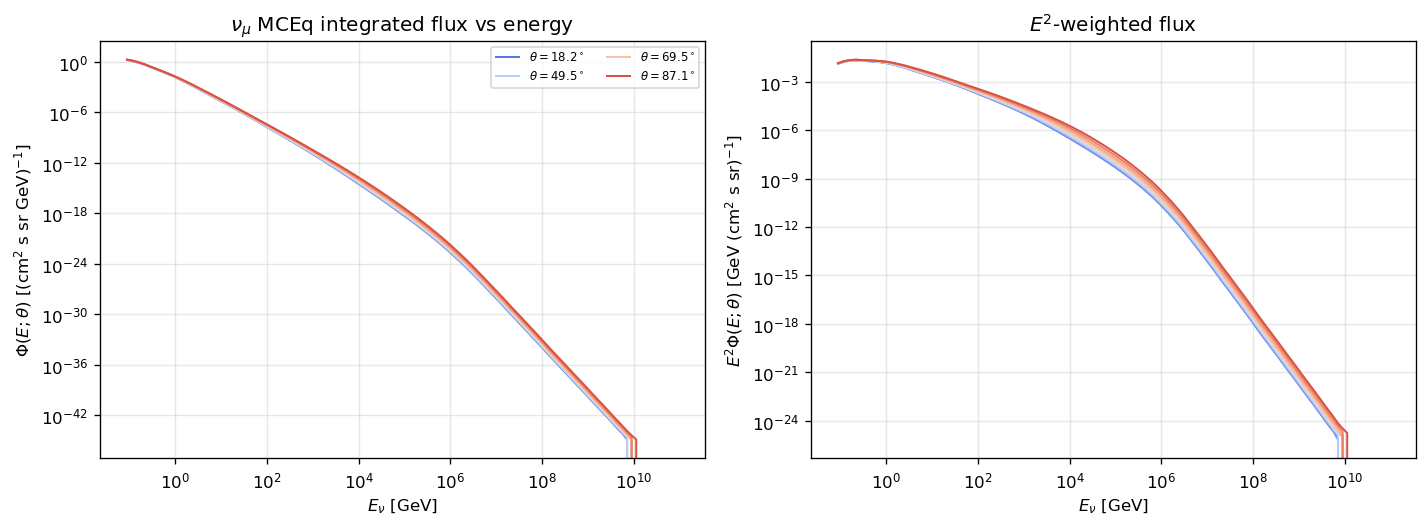

v:\output\analysis\atmosphere\mceq_generator\atm5_fig63_phi_E_theta.png


In [14]:
PARTICLE_SHOW = 'numu'
d           = dataset[PARTICLE_SHOW]
phi_E_theta = d['phi_E_theta'].numpy()    # (n_theta, n_E)
theta_arr   = d['theta_grid_deg'].numpy()
E_arr       = d['E_grid_GeV'].numpy()

colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(theta_arr)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (theta, col) in enumerate(zip(theta_arr, colors)):
    axes[0].loglog(E_arr, phi_E_theta[i], color=col, lw=1.2,
                   label=rf'$\theta={theta:.1f}^\circ$' if i % 3 == 0 else None)
    axes[1].loglog(E_arr, E_arr**2 * phi_E_theta[i], color=col, lw=1.2)

axes[0].set_xlabel('$E_{\\nu}$ [GeV]')
axes[0].set_ylabel(r'$\Phi(E;\theta)$ [(cm$^2$ s sr GeV)$^{-1}$]')
axes[0].set_title(r'$\nu_\mu$ MCEq integrated flux vs energy')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$E_{\\nu}$ [GeV]')
axes[1].set_ylabel(r'$E^2\Phi(E;\theta)$ [GeV (cm$^2$ s sr)$^{-1}$]')
axes[1].set_title(r'$E^2$-weighted flux')

fig.tight_layout()
save_and_show('atm5_fig63_phi_E_theta.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.4 Production-Height PDF $f(h|E,\theta)$

The height density at a fixed reference angle $\theta_0$ for several energies.

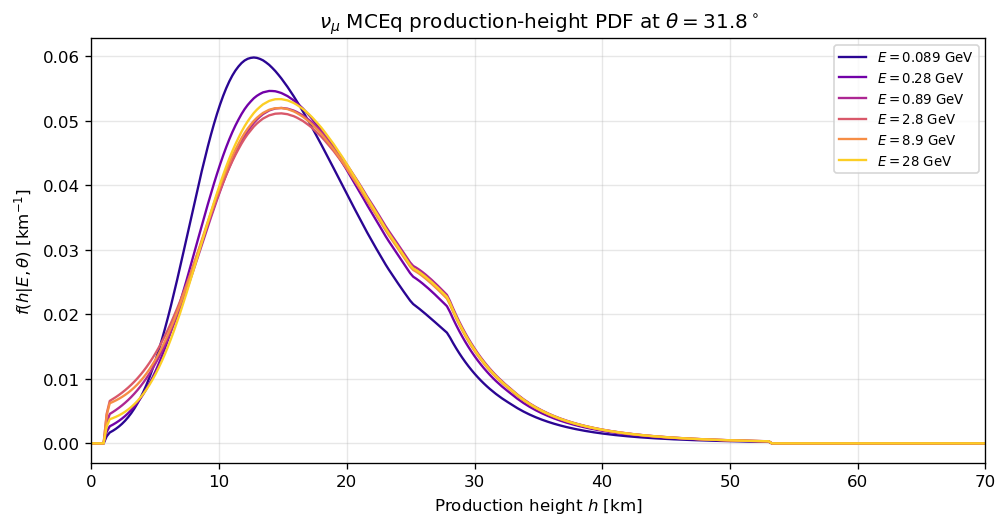

v:\output\analysis\atmosphere\mceq_generator\atm5_fig64_fEh.png


In [15]:
THETA0    = 30.0
i_theta   = int(np.argmin(np.abs(theta_arr - THETA0)))
theta_act = float(theta_arr[i_theta])

f_theta_E_h = dataset[PARTICLE_SHOW]['f_theta_E_h'].numpy()  # (n_theta, n_E, n_h)
h_arr       = dataset[PARTICLE_SHOW]['h_grid_km'].numpy()
f_at_theta  = f_theta_E_h[i_theta]                           # (n_E, n_h)

E_show   = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
colors_e = plt.cm.plasma(np.linspace(0.05, 0.90, len(E_show)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for E_ref, col in zip(E_show, colors_e):
    ie = int(np.argmin(np.abs(E_arr - E_ref)))
    ax.plot(h_arr, f_at_theta[ie], color=col, lw=1.4,
            label=rf'$E={E_arr[ie]:.2g}$ GeV')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel(r'$f(h|E,\theta)$ [km$^{-1}$]')
ax.set_title(rf'$\nu_\mu$ MCEq production-height PDF at $\theta={theta_act:.1f}^\circ$')
ax.legend(fontsize=8)
ax.set_xlim(0, 70)
fig.tight_layout()
save_and_show('atm5_fig64_fEh.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.5 Height-Differential Flux $\Phi(E,h;\theta)$

2-D heatmap of $\log_{10}\Phi(E,h;\theta)$ at the reference angle.
This is the quantity passed to the atmospheric neutrino propagator as the
upper boundary condition.

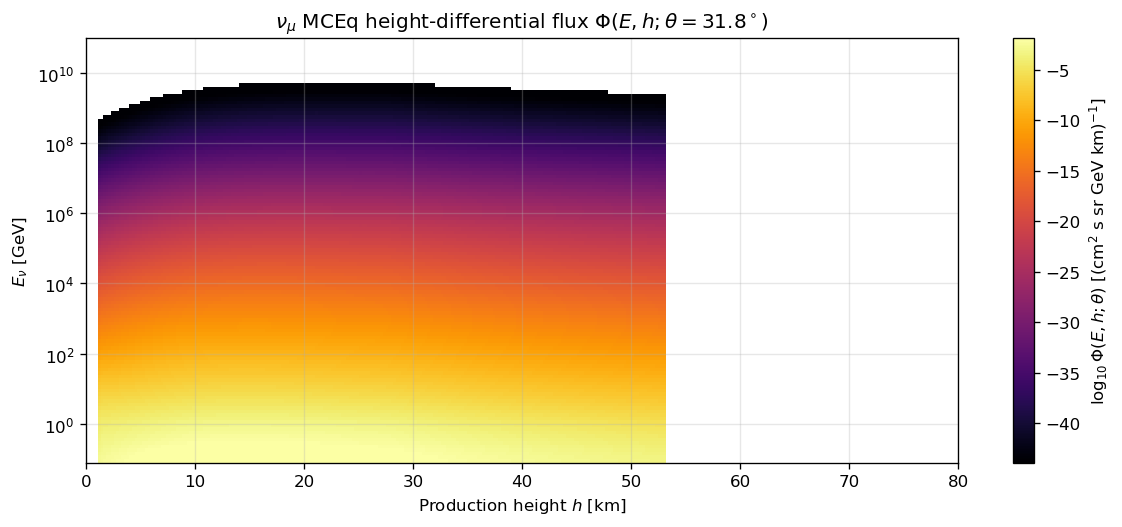

v:\output\analysis\atmosphere\mceq_generator\atm5_fig65_phi_Eh_heatmap.png


In [16]:
phi_E_theta_h = dataset[PARTICLE_SHOW]['phi_E_theta_h'].numpy()  # (n_theta, n_E, n_h)
phi_at_theta  = phi_E_theta_h[i_theta]                            # (n_E, n_h)

with np.errstate(divide='ignore'):
    log_phi = np.where(phi_at_theta > 0, np.log10(phi_at_theta), np.nan)

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.pcolormesh(
    h_arr, E_arr, log_phi,
    cmap='inferno', shading='auto',
    vmin=np.nanpercentile(log_phi, 2),
    vmax=np.nanpercentile(log_phi, 98),
)
cb = fig.colorbar(im, ax=ax)
cb.set_label(r'$\log_{10}\Phi(E,h;\theta)$ [(cm$^2$ s sr GeV km)$^{-1}$]')
ax.set_yscale('log')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel('$E_{\\nu}$ [GeV]')
ax.set_title(rf'$\nu_\mu$ MCEq height-differential flux $\Phi(E,h;\theta={theta_act:.1f}^\circ)$')
ax.set_xlim(0, 80)
fig.tight_layout()
save_and_show('atm5_fig65_phi_Eh_heatmap.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)